In [1]:
# Import libraries
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ogcore.demographics import get_pop

In [2]:
# Set paths
# script_dir = os.path.dirname(os.path.abspath(__file__))
script_dir = (
    "/Users/richardevans/Docs/Economics/OSE/PublicHealth/MacroAgingNature/" +
    "SimulationCode"
)
main_dir = os.path.join(script_dir, "simulation_results")
images_dir = os.path.join(
    os.path.dirname(script_dir), "ResultsInPaper", "figures"
)

In [3]:
end_year = 2050
p_base = pickle.load(
    open(os.path.join(main_dir, "baseline", "model_params.pkl"), "rb")
)
years1 = np.arange(p_base.start_year, end_year + 1)
T1 = len(years1)
# Read in baseline population time path from model output
(
    fert_rates_base_TP,
    mort_rates_base_TP,
    infmort_rates_base_TP,
    imm_rates_base_TP,
    pop_dist_base_TP,
    pre_pop_dist_base
) = pickle.load(open(os.path.join(main_dir, "demog_vars_baseline.pkl"), "rb"))
# Create time series for basline population from 2025 to 2050
base_pop_full_path, _ = get_pop(
    E=20,
    S=80,
    min_age=0,
    max_age=99,
    infer_pop=True,
    fert_rates=fert_rates_base_TP,
    mort_rates=mort_rates_base_TP,
    infmort_rates=infmort_rates_base_TP,
    imm_rates=imm_rates_base_TP,
    initial_pop=pop_dist_base_TP[0, :],
    pre_pop_dist=pre_pop_dist_base,
    start_year=p_base.start_year,
    end_year=end_year,
    download_path=None,
)
tot_pop_2025_2050_base = base_pop_full_path.sum(axis=1)

# Get total population time series from 2025 to 2050 for 1st-gen and 2nd-gen
# scenarios
tot_pop_2025_2050_1gen = pd.read_csv(
    os.path.join(
        main_dir, "1st_gen", "demographic_data", "population_distribution.csv"
    ), header=None
).sum(axis=1).to_numpy()[:T1]

tot_pop_2025_2050_2gen = pd.read_csv(
    os.path.join(
        main_dir, "2nd_gen", "demographic_data", "population_distribution.csv"
    ), header=None
).sum(axis=1).to_numpy()[:T1]

print(
    f"FIG 1: 1st-gen population change relative to baseline in 2050 " +
    f"is {tot_pop_2025_2050_1gen[-1] - tot_pop_2025_2050_base[-1]:,.0f}."
)
print(
    f"FIG 1: 2nd-gen population change relative to baseline in 2050 " +
    f"is {tot_pop_2025_2050_2gen[-1] - tot_pop_2025_2050_base[-1]:,.0f}."
)

FIG 1: 1st-gen population change relative to baseline in 2050 is 275,208.
FIG 1: 2nd-gen population change relative to baseline in 2050 is 1,110,665.


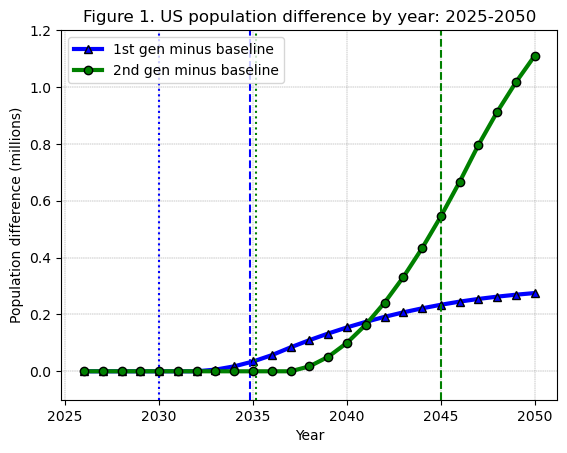

In [6]:
fig1, ax1 = plt.subplots()
ax1.plot(
    years1, (tot_pop_2025_2050_1gen - tot_pop_2025_2050_base)/1e6,
    linestyle='-', linewidth=3, color='blue', marker='^',
    markeredgecolor='black', label='1st gen minus baseline'
)
ax1.vlines(
    x=2030, ymin=-0.1, ymax=1.5, color='blue', linestyle=':',
    # label="2030 begin effective year, 1st gen"
)
ax1.vlines(
    x=2034.85, ymin=-0.1, ymax=1.5, color='blue', linestyle='--',
    # label="2035 full effective year, 1st gen"
)
ax1.plot(
    years1, (tot_pop_2025_2050_2gen - tot_pop_2025_2050_base)/1e6,
    linestyle='-', linewidth=3, color='green', marker='o',
    markeredgecolor='black', label='2nd gen minus baseline'
)
ax1.vlines(
    x=2035.15, ymin=-0.1, ymax=1.5, color='green', linestyle=':',
    # label="2035 begin effective year, 2nd gen"
)
ax1.vlines(
    x=2045, ymin=-0.1, ymax=1.5, color='green', linestyle='--',
    # label="2045 full effective year, 2nd gen"
)
plt.grid(
    visible=True, which='major', axis='both', color='0.5', linestyle='--',
    linewidth=0.3
)
plt.ylim(-0.1, 1.2)
plt.xlabel("Year")
plt.ylabel("Population difference (millions)")
plt.legend()
plt.title("Figure 1. US population difference by year: 2025-2050")
# plt.savefig(os.path.join(images_dir, "fig1_us_popdiff_2nd1stgen.png"))
plt.show()

In [14]:
p_1year = pickle.load(
    open(os.path.join(main_dir, "one_year_all", "model_params.pkl"), "rb")
)
p_1year.rho.shape
# ages2a = np.arange(1, 101)
# surv_rates_base = (1 - mort_rates_base_TP[0, :]).cumprod()
# fig2a, ax2a = plt.subplots()
# ax2a.plot(
#     ages2a, surv_rates_base, linestyle=':', linewidth=3, color='blue',
#     markeredgecolor='blue', label='Baseline 2025'
# )
# plt.grid(
#     visible=True, which='major', axis='both', color='0.5', linestyle='--',
#     linewidth=0.3
# )
# plt.ylim(-0.05, 1.05)
# plt.xlabel("Age")
# plt.ylabel("Cumulative survival rate")
# plt.legend()
# plt.title("Figure 2a. US survival rates by age: 2025")
# plt.savefig(os.path.join(images_dir, "fig2_us_survrates_2025.png"))
# plt.show()

(400, 80)

In [19]:
p_base.omega.shape

(400, 80)

In [20]:
pop_dist_base_TP.shape

(2, 100)

In [23]:
base_pop_full_long_path, _ = get_pop(
    E=20,
    S=80,
    min_age=0,
    max_age=99,
    infer_pop=True,
    fert_rates=fert_rates_base_TP,
    mort_rates=mort_rates_base_TP,
    infmort_rates=infmort_rates_base_TP,
    imm_rates=imm_rates_base_TP,
    initial_pop=pop_dist_base_TP[0, :],
    pre_pop_dist=pre_pop_dist_base,
    start_year=p_base.start_year,
    end_year=p_base.start_year + p_base.T,
    download_path=None,
)
base_pop_full_long_path.shape

(321, 100)